In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength


In [ ]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Effective index of a waveguide

### Convergence Tests narrow waveguide

In [ ]:
n_eff_matrix=[]
grid_res=[]
for i in range(10,60,6):
    deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450*nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid 
    grid_resolution=i, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    )
    n_eff_matrix.append(deep_waveguide.n_eff.real)
    grid_res.append(i)

print (n_eff_matrix)

2026-04-13 14:31:28.258 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c02103117cd3353d.npz.
2026-04-13 14:31:28.304 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_9add4fd903f4ddef.npz.
2026-04-13 14:31:28.311 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e4b21cf341ca1045.npz.
2026-04-13 14:31:28.318 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_98558efae674c6ad.npz.
2026-04-13 14:31:28.326 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ab9e8a77506bb3c6.npz.
2026-04-13 14:31:28.333 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5cb34e7bb1c6d7d6.npz.
2026-04-13 14:31:28.340 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8dd026cfb6f99ece.npz.
2026-04-13 14:31:28.347 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3a769b98ac0b1fad.npz.


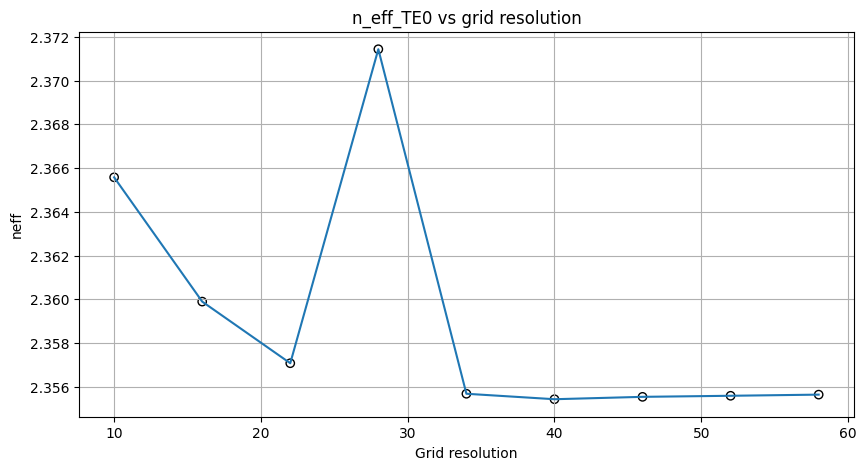

In [ ]:

plt.figure(figsize=(10, 5))
plt.scatter(grid_res, n_eff_matrix,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(grid_res, n_eff_matrix)
plt.title(f"n_eff_TE0 vs grid resolution")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()

Como observamos el valor más pequeño que tiene un valor similar es el de 40, de manera que valos a tomar ese valor para el menor coste computacional. Pues de esa manera tenemos la maya con menos puntos de simulación.

In [ ]:
#Para 40 de grid resolution

n_eff_matrix_sca50=[]
grid_scaling=[]
for i in range(20,70,5):
    deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450*nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1+(i/100), # Parameters of the grid 
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    )
    n_eff_matrix_sca50.append(deep_waveguide.n_eff.real)
    grid_scaling.append(1+i/100)

print(n_eff_matrix_sca50)
print(grid_scaling)

2026-04-13 14:31:36.043 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_9efc89966753b23b.npz.
2026-04-13 14:31:36.053 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b4f3e0902a167872.npz.
2026-04-13 14:31:36.059 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_fcef14e0c30fac31.npz.
2026-04-13 14:31:36.066 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2d26a7bf6cc246c8.npz.
2026-04-13 14:31:36.073 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_890e55709babd941.npz.
2026-04-13 14:31:36.078 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bb03871f987200b8.npz.
2026-04-13 14:31:36.083 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5cb34e7bb1c6d7d6.npz.
2026-04-13 14:31:36.090 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c59ac5f9152f79bd.npz.


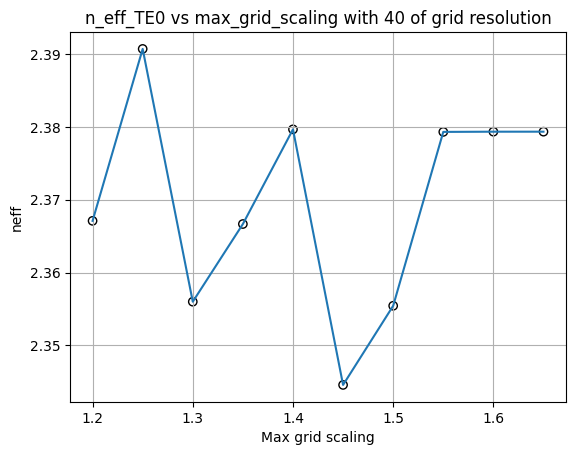

In [ ]:


plt.scatter(grid_scaling, n_eff_matrix_sca50,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(grid_scaling, n_eff_matrix_sca50)
plt.title(f"n_eff_TE0 vs max_grid_scaling with 40 of grid resolution")
plt.xlabel("Max grid scaling")
plt.ylabel("neff")
plt.grid()

De manera que para las simulaciones vamos a usar 40 de grid resolution y 1.6 de max grid resolution.

### wide waveguide 

In [ ]:
n_eff_matrix=[]
grid_res=[]
for i in range(10,60,6):
    deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=650*nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid 
    grid_resolution=i, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    )
    n_eff_matrix.append(deep_waveguide.n_eff.real)
    grid_res.append(i)

print (n_eff_matrix)

/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d

14:32:08 -05 WARNING: The group index was not computed. To calculate group      
             index, pass 'group_index_step = True' in the 'ModeSpec'.           

2026-04-13 14:32:08.345 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_d45841c3e6fbca2e.npz.


/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d

2026-04-13 14:32:10.605 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_6523184bba62919c.npz.


...

2026-04-13 14:32:56.105 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_225a19abb9cbb4de.npz.


/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d

2026-04-13 14:33:19.805 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_312d614f39255845.npz.


/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-final-project-PO/.venv/lib/python3.12/site-packages/tidy3d

2026-04-13 14:33:58.968 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_a33fc94515fd7f76.npz.
[array(2.61508228), array(2.6114506), array(2.60919306), array(2.60848621), array(2.60817797), array(2.6117827), array(2.60484316), array(2.60831153), array(2.6084066)]


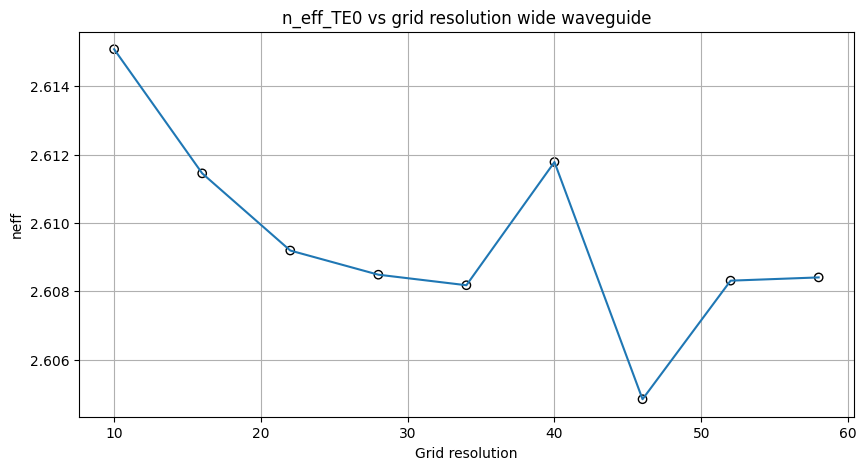

In [ ]:

plt.figure(figsize=(10, 5))
plt.scatter(grid_res, n_eff_matrix,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(grid_res, n_eff_matrix)
plt.title(f"n_eff_TE0 vs grid resolution wide waveguide")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()

In [ ]:
#Para 30 de grid resolution

n_eff_matrix_sca50=[]
grid_scaling=[]
for i in range(20,70,5):
    deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=650*nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1+(i/100), # Parameters of the grid 
    grid_resolution=30, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    )
    n_eff_matrix_sca50.append(deep_waveguide.n_eff.real)
    grid_scaling.append(1+i/100)

print(n_eff_matrix_sca50)
print(grid_scaling)

2026-04-13 14:41:04.927 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7fff7f083457ba8e.npz.
2026-04-13 14:41:04.939 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8a6fffd277d0e8d7.npz.
2026-04-13 14:41:04.947 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_88e3e2a5e11ccdee.npz.
2026-04-13 14:41:04.954 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8c41c6b892340425.npz.
2026-04-13 14:41:04.962 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8b831f38fb14d090.npz.
2026-04-13 14:41:04.971 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_90937f1d0f087cd3.npz.
2026-04-13 14:41:04.977 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0c8294fef54264a2.npz.
2026-04-13 14:41:04.987 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_22ed64bd3ba5c915.npz.


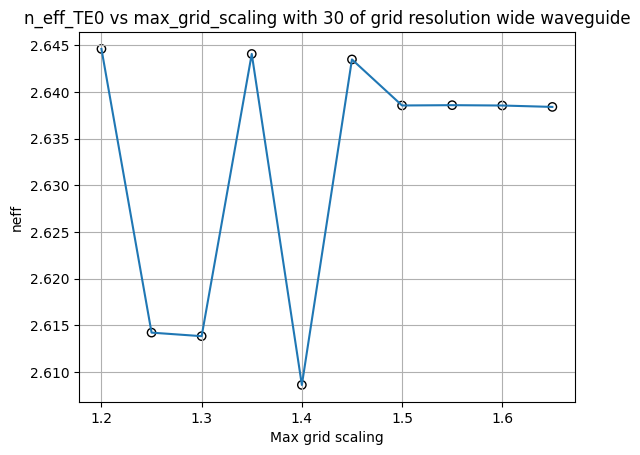

In [ ]:


plt.scatter(grid_scaling, n_eff_matrix_sca50,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(grid_scaling, n_eff_matrix_sca50)
plt.title(f"n_eff_TE0 vs max_grid_scaling with 30 of grid resolution wide waveguide")
plt.xlabel("Max grid scaling")
plt.ylabel("neff")
plt.grid()

En el caso de la wide waveguide, se debe usar como parámetros 30 de grid resolution y 1.6 de max_grid_scaling, pues como se vio en las gráficas, es donde obtenemos un valor de indice efectivo más estable. 